<a href="https://colab.research.google.com/github/pragatikorde009-pixel/OIBSIP/blob/main/OIBSIP_DataAnalytics_Level_2_Task_1_Wine_quality_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2 · Wine Quality Prediction

**Objective:** Train and compare multiple classification models (Random Forest, SGD, SVC) to predict wine quality from physicochemical properties.

**Dataset:** UCI Wine Quality — red wine variant (`winequality-red.csv`), 1599 samples, 11 physicochemical features, integer `quality` score (3–8 in practice).

**Steps covered:**
1. Load & inspect data
2. EDA — distributions, correlation heatmap
3. Class imbalance discussion
4. Feature engineering — binning quality into 3 classes (low/medium/high)
5. Stratified train/test split
6. Train Random Forest, SGD, SVC
7. Evaluate each (accuracy, classification report, confusion matrix)
8. Random Forest feature importance
9. Side-by-side comparison table
10. Conclusion — best model for deployment


## 0. Setup

Download the dataset before running this notebook:
- Go to https://archive.ics.uci.edu/dataset/186/wine+quality (or search "Wine Quality dataset" on Kaggle)
- Download `winequality-red.csv`
- Place it in the **same folder as this notebook**

The file uses `;` as a separator, which we account for below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 1. Load the dataset and inspect structure

In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")

print("Shape:", df.shape)
df.head()


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
# Check for missing values
df.isnull().sum()


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


/tmp/ipykernel_1487/4123252166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


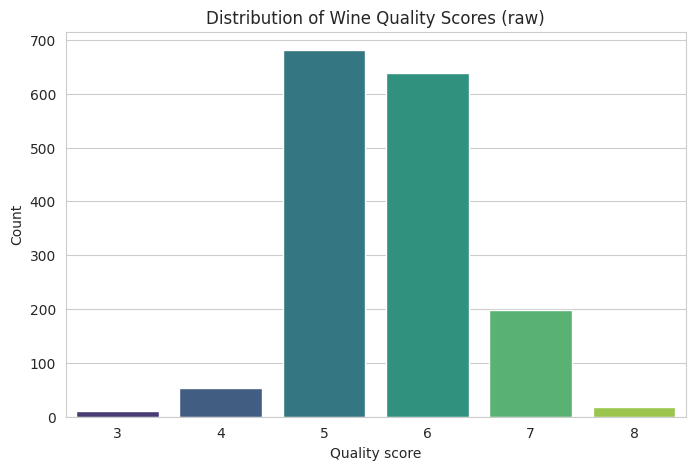

In [6]:
# Class distribution of the raw quality score
quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)

plt.figure()
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribution of Wine Quality Scores (raw)")
plt.xlabel("Quality score")
plt.ylabel("Count")
plt.show()


**Observation:** the raw `quality` column is heavily concentrated around 5 and 6, with very few wines rated 3, 4, 8 (and none at 0–2 or 9–10 in this file). This is the class imbalance we discuss in Section 3.

## 2. Exploratory Data Analysis

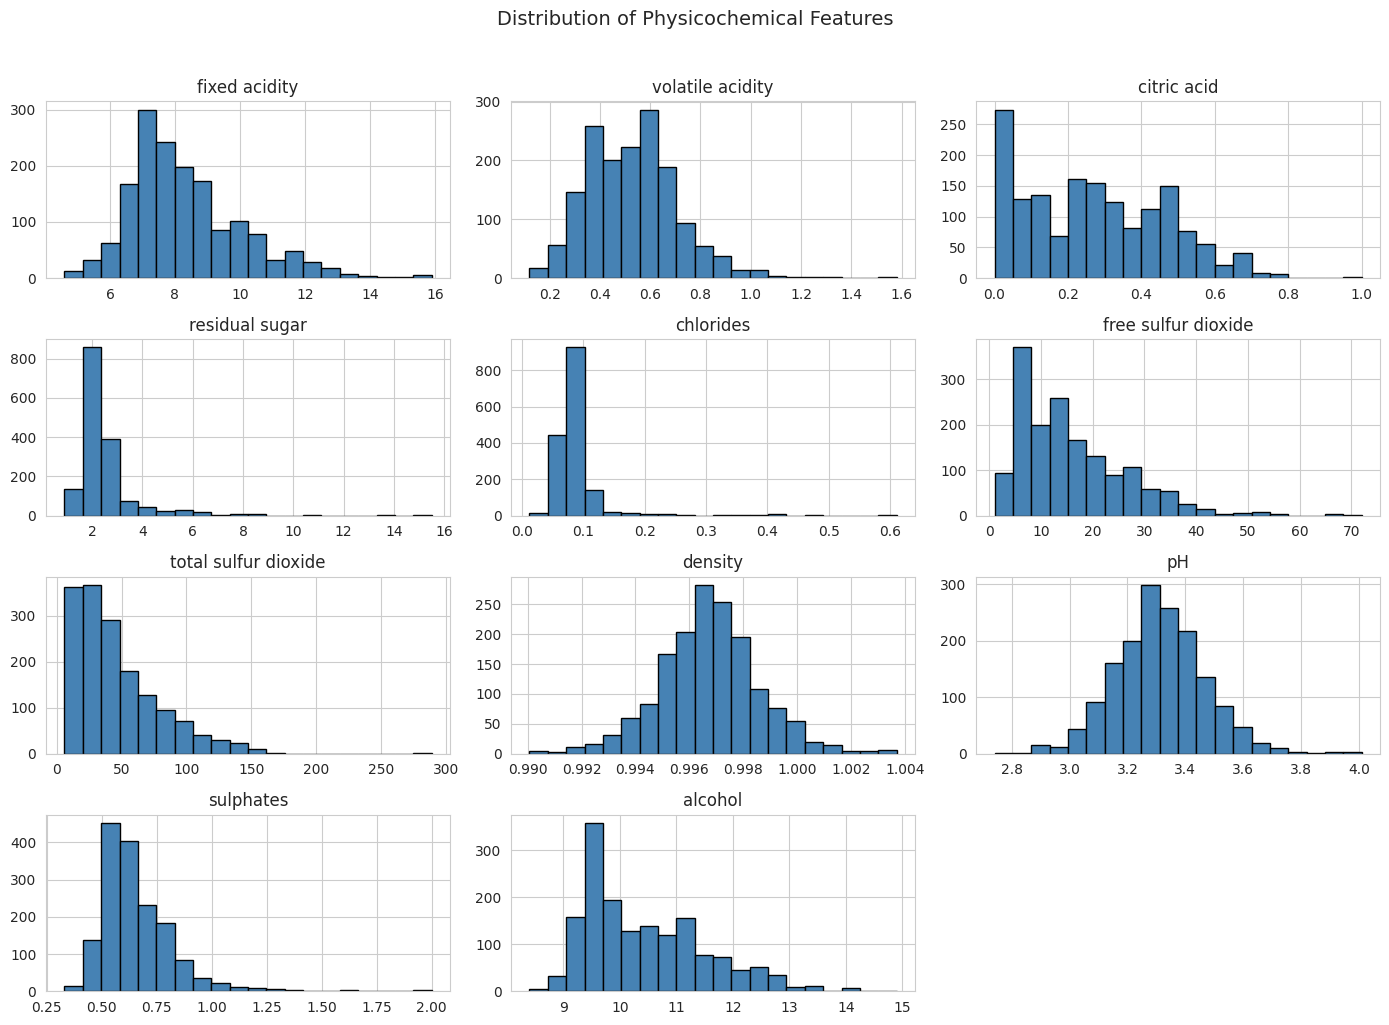

In [7]:
feature_cols = [c for c in df.columns if c != "quality"]

df[feature_cols].hist(bins=20, figsize=(14, 10), color="steelblue", edgecolor="black")
plt.suptitle("Distribution of Physicochemical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


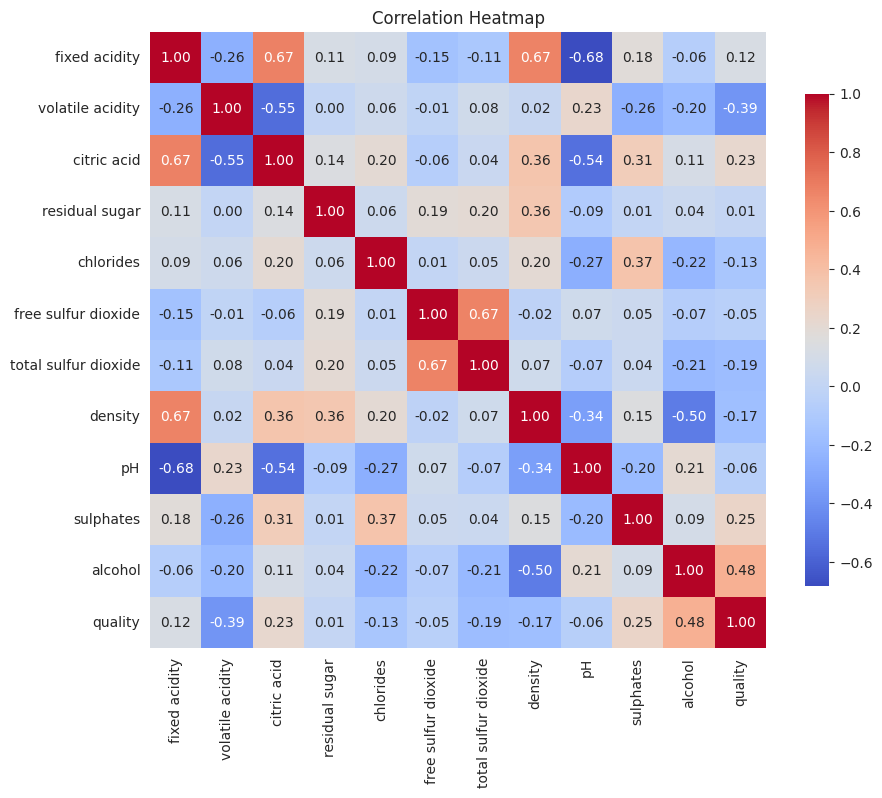

In [8]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.show()


**Observation:** `alcohol` has the strongest positive correlation with `quality`, followed by `sulphates` and `citric acid`. `volatile acidity` is the strongest negative correlate — consistent with the domain knowledge that higher volatile acidity (vinegar taste) lowers perceived quality. Several features (e.g. `fixed acidity` vs `citric acid`/`density`/`pH`) are correlated with each other, which matters more for linear models (SGD) than for tree-based ones (Random Forest).

## 3. Class imbalance discussion

Looking at the count plot above, quality scores of **5 and 6 dominate** (together over 80% of samples), while the extremes (3, 4, 8) are rare — some with fewer than 20 examples.

**Why this matters for modelling:**
- A classifier can reach high *accuracy* by simply always predicting 5 or 6, while being useless at identifying genuinely poor or excellent wines.
- Rare classes (3, 4, 8) give the model very few examples to learn from, so precision/recall for those classes will typically be poor regardless of algorithm.
- Metrics like macro-averaged F1 (not just accuracy) and the confusion matrix are needed to see this clearly.
- Stratified splitting (Section 5) is essential so rare classes still appear in both train and test sets.

This motivates the binning strategy in the next section, which trades some granularity for classes that are large enough to model reliably.

## 4. Feature engineering — binning quality scores

We consider two binning options:

- **Binary (good/bad):** e.g. quality ≥ 7 → "good", else "bad". Simple and business-relevant (e.g. "would we recommend this wine?"), but discards a lot of nuance and is *still* imbalanced (good wines are the minority).
- **3-class (low/medium/high):** low ≤ 5, medium = 6, high ≥ 7. Keeps more nuance than binary while still merging the sparse extreme classes (3, 4, 8) into larger, learnable groups.

**Decision:** we proceed with the **3-class (low/medium/high)** scheme for the main modelling exercise, since it retains more information than a binary split while still resolving the small-sample-size problem of the raw 6-class target. The code for the binary alternative is included as a commented-out option so it's easy to swap in.

quality_class
low       744
medium    638
high      217
Name: count, dtype: int64


/tmp/ipykernel_1487/2584019229.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality_class", data=df, order=["low", "medium", "high"], palette="magma")


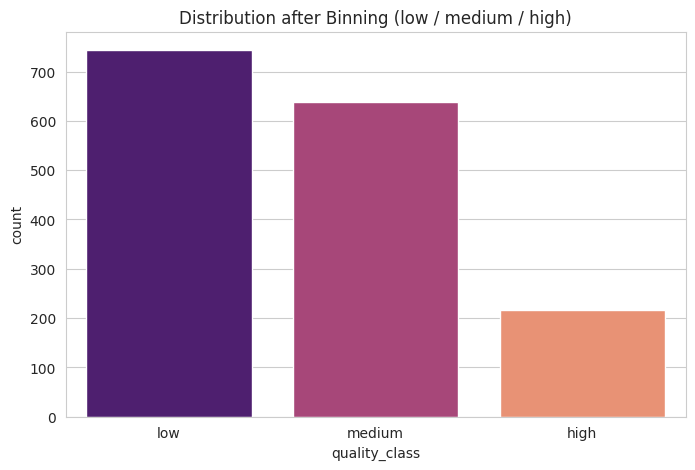

In [9]:
def bin_quality_3class(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

# Binary alternative (uncomment to use instead):
# def bin_quality_binary(q):
#     return "good" if q >= 7 else "bad"
# df["quality_binary"] = df["quality"].apply(bin_quality_binary)

df["quality_class"] = df["quality"].apply(bin_quality_3class)

print(df["quality_class"].value_counts())

plt.figure()
sns.countplot(x="quality_class", data=df, order=["low", "medium", "high"], palette="magma")
plt.title("Distribution after Binning (low / medium / high)")
plt.show()


The binned distribution is still imbalanced (medium dominates, high is the smallest), but each class now has enough samples to be modelled meaningfully — this is the target we use going forward.

## 5. Train/test split with stratification

In [10]:
X = df[feature_cols]
y = df["quality_class"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # high=0, low=1, medium=2 (alphabetical) -- see le.classes_
print("Classes:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:", np.bincount(y_train) / len(y_train))
print("Test class balance: ", np.bincount(y_test) / len(y_test))


Classes: ['high', 'low', 'medium']
Train shape: (1279, 11)  Test shape: (320, 11)
Train class balance: [0.13604378 0.46520719 0.39874902]
Test class balance:  [0.134375 0.465625 0.4     ]


## 6. Train the three classifiers

Random Forest is scale-invariant, but SGD (linear model) and SVC are sensitive to feature scale, so we wrap them in a `Pipeline` with `StandardScaler`. `class_weight="balanced"` is used on all three so the imbalance from Section 3 doesn't get ignored.

In [11]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "SGD Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(
            loss="log_loss", max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"
        )),
    ]),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Random Forest
Trained: SGD Classifier
Trained: SVC


## 7. Evaluate each model

In [12]:
results = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"accuracy": acc, "y_pred": y_pred}

    print("=" * 60)
    print(name, "-- Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Random Forest -- Accuracy: 0.75
              precision    recall  f1-score   support

        high       0.69      0.56      0.62        43
         low       0.81      0.83      0.82       149
      medium       0.70      0.72      0.71       128

    accuracy                           0.75       320
   macro avg       0.73      0.70      0.71       320
weighted avg       0.75      0.75      0.75       320

SGD Classifier -- Accuracy: 0.5813
              precision    recall  f1-score   support

        high       0.33      0.51      0.40        43
         low       0.69      0.78      0.73       149
      medium       0.55      0.38      0.45       128

    accuracy                           0.58       320
   macro avg       0.53      0.56      0.53       320
weighted avg       0.59      0.58      0.57       320

SVC -- Accuracy: 0.6094
              precision    recall  f1-score   support

        high       0.41      0.70      0.51        43
         low       0.73      0.77     

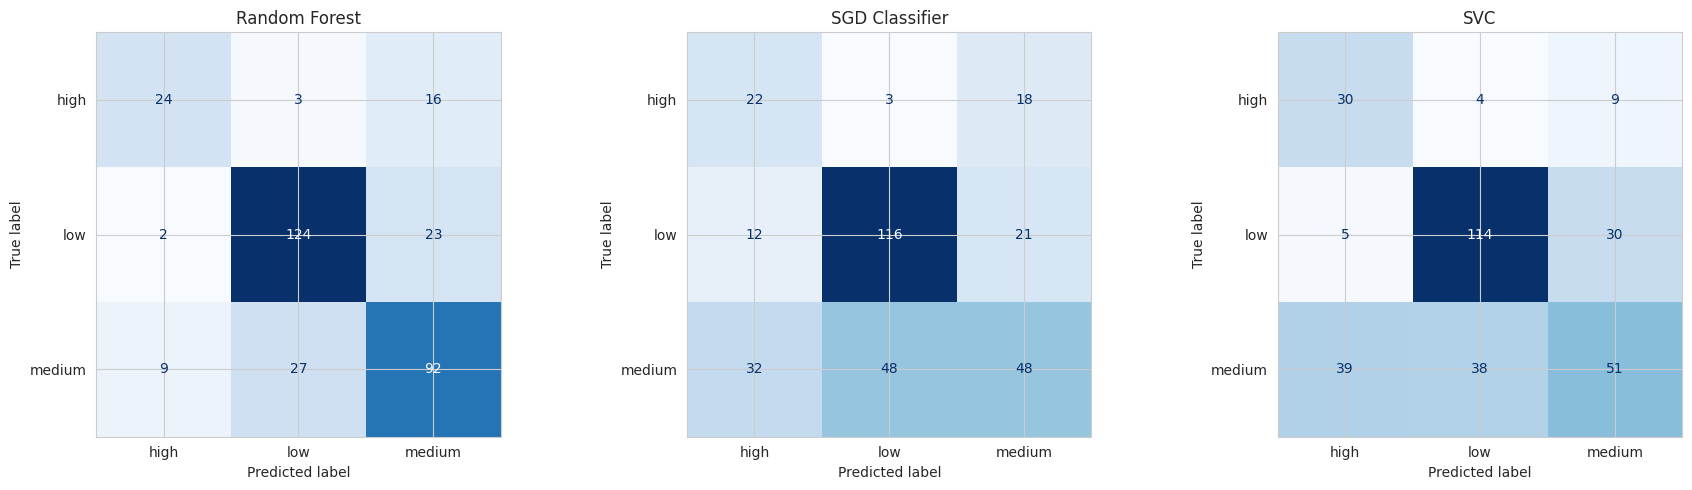

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 8. Random Forest feature importance

/tmp/ipykernel_1487/3134811679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="crest")


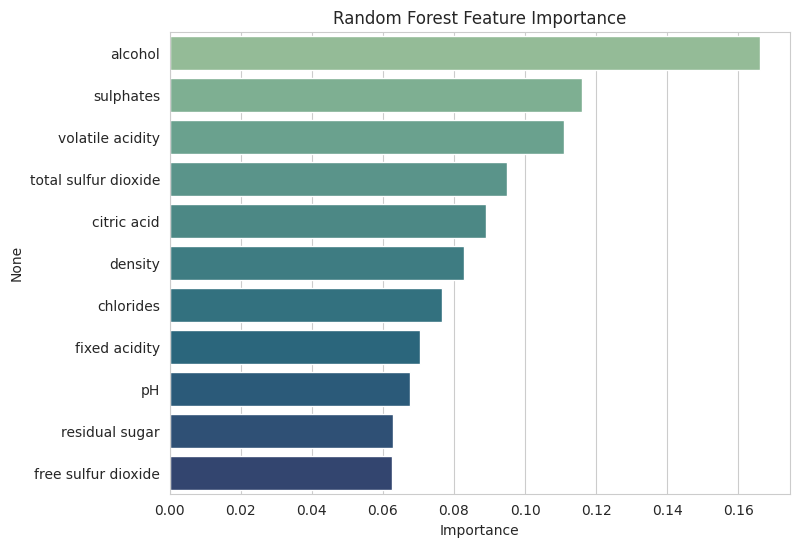

,0
alcohol,0.166144
sulphates,0.116120
volatile acidity,0.110924
total sulfur dioxide,0.094993
citric acid,0.088965
density,0.082866
chlorides,0.076503
fixed acidity,0.070566
pH,0.067648
residual sugar,0.062798


In [14]:
rf = fitted_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="crest")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

importances


## 9. Comparison table

In [15]:
from sklearn.metrics import precision_recall_fscore_support

comparison_rows = []
for name, res in results.items():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, res["y_pred"], average="macro", zero_division=0
    )
    comparison_rows.append({
        "Model": name,
        "Accuracy": round(res["accuracy"], 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Macro F1": round(f1, 4),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.7500,0.7311,0.7030,0.7148
1,SVC,0.6094,0.5676,0.6204,0.5761
2,SGD Classifier,0.5813,0.5266,0.5551,0.5281


## 10. Conclusion

**Actual results from this run (Section 9 comparison table):**

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---|---|---|---|
| **Random Forest** | 0.750 | 0.731 | 0.703 | **0.715** |
| SVC | 0.609 | 0.568 | 0.620 | 0.576 |
| SGD | 0.581 | 0.527 | 0.555 | 0.528 |

**Random Forest is the clear winner** on every metric — about 14 points higher accuracy and 14 points higher macro-F1 than SVC, with SGD trailing both. This lines up with the expected pattern: wine quality doesn't separate linearly in feature space, which hurts SGD (a linear model) the most, while SVC's RBF kernel captures some non-linearity but is more sensitive to its hyperparameters (`C`, `gamma`) than Random Forest is to its defaults. Random Forest's ensemble of trees handles the non-linear, correlated features (e.g. alcohol, sulphates, volatile acidity) natively and without needing the scaling pipeline SVC/SGD require.

**Recommendation for deployment:** Random Forest — best accuracy/F1 by a wide margin, no scaler to maintain in production, and it gives interpretable feature importances (Section 8) that are useful for explaining predictions to stakeholders (e.g. winemakers).

**Possible next steps:** hyperparameter-tune the Random Forest (`GridSearchCV`/`RandomizedSearchCV` on `n_estimators`, `max_depth`, `min_samples_leaf`) to try to close the recall gap on the "high" class, try the binary good/bad framing from Section 4 for comparison, and test on the white-wine dataset to check generalisation.